This notebook produces Figure 3, which takes the USDA Cropland Data Layer (CDL) road mask which has already been converted into radar coordinates, and separates surface cover types to produce masks for desert, urban+barren, and vegetated areas. The desert mask is produced manually with the draw_polygon_to_mask_desert.ipynb notebook. 
<br><br>
The file roadarray.r4 was produced by first running this: https://github.com/kdevlin525/InSAR-calculations/blob/main/notebooks/ungeo_cropscape.ipynb 
then this: https://github.com/kdevlin525/C-band-phase-bias/blob/main/segment_fields.ipynb and was performed by coauthor Kelly Devlin.
<br><br>
Use the "earthscope_insar" conda environment as the Python kernel for this and all subsequent notebooks.
***

In [1]:
# import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib  widget

In [2]:
# make a custom colormap for the three surface types we want to separate
colors = ['goldenrod','lightgreen','mediumslateblue']
cmap_mine = ListedColormap(colors)

In [3]:
# Define the size of the image/masks
dx = 9000
dy = 1575

At this stage, the roadarray.r4 and no_desert.r4 files need to be created. See PUT_FILENAME_HERE for instructions.

In [4]:
# load in the two masks we need: roads and non-desert

# road mask from CDL
f1 = gdal.Open('roadarray.r4', gdal.GA_ReadOnly)
roads = f1.ReadAsArray()+1   
# mask of 1s (vegetation) and 2s (NVG) 
f1 = None

f1 = gdal.Open('no_desert.r4', gdal.GA_ReadOnly)
no_desert = f1.ReadAsArray() 
# mask of 1s (desert) and 0s (not desert)  
no_desert_flipped = np.where(no_desert==1,0,1)
# mask of 1s (not desert) and 0s (desert)
f1 = None

# now change them such that 0=desert, 1=vegetation, 2=urban+barren
updated_roads = no_desert_flipped * roads

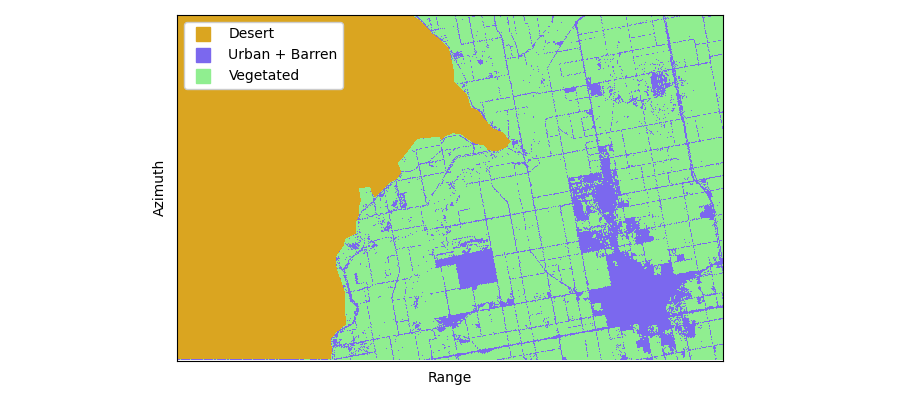

In [5]:
plt.figure(figsize=(9,4),tight_layout=True)
plt.imshow(updated_roads,aspect=(21.8/dy)/(34.44/dx),interpolation='none',cmap=cmap_mine)
plt.plot(-100,-100,marker='s',ms=10,linestyle='none',color=colors[0],label='Desert')
plt.plot(-100,-100,marker='s',ms=10,linestyle='none',color=colors[2],label='Urban + Barren')
plt.plot(-100,-100,marker='s',ms=10,linestyle='none',color=colors[1],label='Vegetated')
plt.xlim(9000,0); plt.ylim(1575,0)
plt.xticks([]); plt.yticks([])
#plt.title('NVG Pixel Mask')
plt.legend(loc='upper left',framealpha=1.0)
plt.xlabel('Range'); plt.ylabel('Azimuth')
plt.show()
#plt.savefig('desert_urban_veg_mask.png',transparent=True,bbox_inches='tight',dpi=500)